# Issue 6a: ESMFold2 Hyperparameter tuning.

> **Author:** Alexander Leonardos\
> **Date Started:** July 25th, 2026\
> **Date Finished:** July 26th, 2026\
> **Input:** `s3://petadex/logan/petadex.catalytic_orfs.v1.1.fa` - Note that this is from Petadex V1, which is fine for this benchmarking experiment.
> **Output:** `s3://petadex-protein-structures/esmfold2_paramsweep/`

---

## Objective

The goal of this notebook is to figure out which hyperparameters of ESMFold2 should be used for the centroid folding experiments that make up the rest of issue 6.

### Place in the Project

This set of experiments has to do with benchmarking ESMFold2, which will be used for structural modelling of the PETadex. This will eventually be used for downstream structural analysis such as Foldseek, as well as various featurization methods for the ML activity predictor.

## 0. Deps

In [ ]:
# Install the required packages with the versions used for the analysis.
import sys, subprocess

PACKAGES = [
    # this notebook + compare_predictions.py (scoring)
    "numpy==2.4.6",
    "matplotlib==3.11.1",
    "boto3==1.43.56",
    "botocore==1.43.56",
    "tmtools==0.3.0",
    "biopython==1.87",
    # Step 2a/2b preprocessing scripts (pdb_to_orfid_map.py, pdb_leakage_filter.py; run standalone)
    "polars==1.40.1",
    "zstandard==0.25.0",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PACKAGES], check=True)
print("installed:", ", ".join(PACKAGES))

## 1. Config + paths

In [ ]:
import csv, random
from pathlib import Path

S3_ORFS = "s3://petadex/logan/petadex.catalytic_orfs.v1.1.fa"

# locate repo root (dir containing resources/) from wherever the kernel started
REPO = Path.cwd()
while not (REPO / "resources").exists() and REPO != REPO.parent:
    REPO = REPO.parent
RES = REPO / "resources" / "260706_issue6_foldpredictions"
MAP = RES / "pdb_orfid_map_dated.tsv"

IDS_TXT   = RES / "paramfoldids.txt"                                  # ORFids for seqkit grep (this nb writes it)
OUT_FASTA = RES / "paramfold_orfs_clean491_plus_controls.fasta"       # the WSL command writes this
OUT_META  = RES / "paramfold_orfs_metadata.tsv"                       # orfid -> role/pdb/len (this nb writes it)

N_CONTROLS   = 30      # positive controls sampled from the leakage-set direct-PDB pool
SEED         = 0
ESMC_CONTEXT = 2048    # ORFs longer than this get truncated by the ESMC backbone

assert MAP.exists(), f"map not found: {MAP}"
print("repo:", REPO)
print("ids :", IDS_TXT)
print("fa  :", OUT_FASTA)

## 2. Make the Subset we will be testing on:

This subset will consist of ORFs that have a ground-truth PDB. Additionally, most of this subset will have ground truths from after the ESMFold2 training cut-off, but will include some from before the training cutoff as a positive control.

### 2a. Find which ORFIds have a PDB Structure, and map catalytic cores ORFIDs -> PDB structures (direct accession + via UniProt). This is ok since the cores and the full sequences from the ORFs file share the same ORFids.

IN:  
- `s3://petadex/logan/petadex.complete_catalytic_cores.v1.1.fa.zst` - Accessed on 05/17/26. (This is PETadex V1.)

- `idmapping_selected.tab.gz` - downloadable from `https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/idmapping/`

OUT: pdb_orfid_map.tsv, pdb_to_orfids.json

To do this, run this python after the downloads are complete.

```
python resources/260706_issue6_foldpredictions/pdb_to_orfid_map.py
```

### 2b. Attach RCSB release dates + leakage flags

IN:  
- pdb_orfid_map.tsv (From previous step)
- Fetches release dates from the live RCSB GraphQL API (needs network); caches to pdb_dates.tsv, so re‑runs are offline unless --force.

OUT:
- pdb_orfid_map_dated.tsv

Leakage rule: an ORF is **clean** if it has a `direct` PDB released after
2021-09-30 (never in ESMFold2's training weights); **control** = a pre-cutoff
direct PDB (the metric's memorized ceiling). Raw inputs (cores `.zst`, UniProt
idmapping, `accessions/`) are large external data — sourced from petadex / UniProt,
not committed.

To do this, run this python script.

```
python resources/260706_issue6_foldpredictions/pdb_leakage_filter.py
```

### 2c. Select the initial fold-target ORFids and emit the WSL fetch command

From the leakage-classified map, choose what to fold and write the ORFid list the
WSL step will pull:

- **clean** = every ORF with at least one PDB released after the 2021-09-30
  cutoff (leakage-free ground truth);
- **control** = a seeded random sample (N=30, seed=0) of ORFs whose only PDB is a
  pre-cutoff `direct` structure (deliberate leakage → the metric's ceiling).

One ORFid can map to several PDB rows, so it keeps one representative row per ORFid
(preferring `direct` provenance). Writes the bare ORFids to `paramfoldids.txt`, then
prints a ready-to-run WSL one-liner (`aws s3 cp … | pv | seqkit grep … | awk …`)
that streams the S3 ORFs file, greps those ORFids, and rewrites each header to
`>orf<ORFid>` so the folded outputs stay keyed by ORFid and joinable to the PDB
ground truth.

OUT: `paramfoldids.txt` (+ the printed WSL command → produces
`paramfold_orfs_clean491_plus_controls.fasta`)

In [ ]:
# One ORFid can have several rows (multiple PDB chains); keep one representative row per ORFid,
# preferring a `direct` provenance PDB. Classify by the leakage flag.
meta = {}   # orfid -> dict(pdb_id, provenance, core_range, post_train, uniprot)
clean_all, clean_direct, leak_direct = set(), set(), set()

with open(MAP, newline="") as fh:
    for d in csv.DictReader(fh, delimiter="\t"):
        try:
            oid = int(d["orfid"])
        except (ValueError, KeyError):
            continue
        post_train = d["post_train_2021_09_30"].strip().lower() == "true"  # True = released AFTER cutoff = clean
        direct     = d["provenance"].strip() == "direct"
        if oid not in meta or (direct and meta[oid]["provenance"] != "direct"):
            meta[oid] = {"pdb_id": d["pdb_id"], "provenance": d["provenance"],
                         "core_range": d["core_range"], "post_train": post_train,
                         "uniprot": d.get("uniprot", "")}
        if post_train:
            clean_all.add(oid)
            if direct:
                clean_direct.add(oid)
        elif direct:
            leak_direct.add(oid)

random.seed(SEED)
controls = set(random.sample(sorted(leak_direct), min(N_CONTROLS, len(leak_direct))))
targets  = clean_all | controls
role = {oid: ("clean" if oid in clean_all else "control") for oid in targets}

IDS_TXT.write_text("".join(f"{oid}\n" for oid in sorted(targets)), encoding="utf-8")  # bare ORFids

print(f"clean_all (491?): {len(clean_all)}  (direct {len(clean_direct)})")
print(f"controls sampled: {len(controls)} of {len(leak_direct)} leakage-direct")
# print the ABSOLUTE path + confirm it landed, so the WSL path below always has a file behind it
print(f"wrote {len(targets)} ORFids -> {IDS_TXT}   (exists: {IDS_TXT.exists()})\n")

# --- ready-to-run WSL command (real /mnt/<drive> paths) ---
def to_wsl(p):
    p = str(p)
    return f"/mnt/{p[0].lower()}" + p[2:].replace("\\", "/")

print(f"# in WSL, verify the ids file is visible first:\n#   ls -l {to_wsl(IDS_TXT)}\n")
print("Then run:\n")
cmd = [
    f"aws s3 cp {S3_ORFS} - --no-sign-request \\",
    "  | pv -s 100g \\",
    f"  | seqkit grep --id-regexp '^([^|]+)' -f {to_wsl(IDS_TXT)} \\",
    "  | awk '/^>/{split(substr($0,2),a,\"|\"); print \">orf\" a[1]; next} {print}' \\",
    f"  > {to_wsl(OUT_FASTA)}",
]
print("\n".join(cmd))

### 2d. Fetch the ORFs in WSL

WSL Package Versions:
- aws: aws-cli/1.45.28 Python/3.12.3 Linux/6.18.33.2-microsoft-standard-WSL2 botocore/1.43.28
- pv: 1.8.5
- seqkit: v2.3.0

Run the command printed above in a **WSL** shell (needs `aws`, `pv`, `seqkit`). It:
- `aws s3 cp ... - --no-sign-request` → streams the public ORFs file to stdout, no sign-in;
- `seqkit grep --id-regexp '^([^|]+)' -f foldids.txt` → keeps only records whose ORFid (first
  `|`-field) is in our list;
- `awk ...` → rewrites `>3|7QJM|||||/95-371` to `>orf3`, so folded outputs are ORFid-keyed and join
  cleanly to the PDB ground truth.

`seqkit grep` scans the whole stream (no early stop), so this reads the entire file — `pv`'s `100g`
is just a progress estimate. Do **not** pipe through `seqkit seq -s` (that drops the ORFid).

### 2e. Load the FASTA → finalize metadata + length histogram

This was used to assess the length of the pulled dataset.

FASTA has 521 ORFs (targets=521)
wrote paramfold_orfs_metadata.tsv

n=521  min=190  median=342  mean=446  p90=638  max=4548   |  8 over 2048aa
mode=270  (count=10)


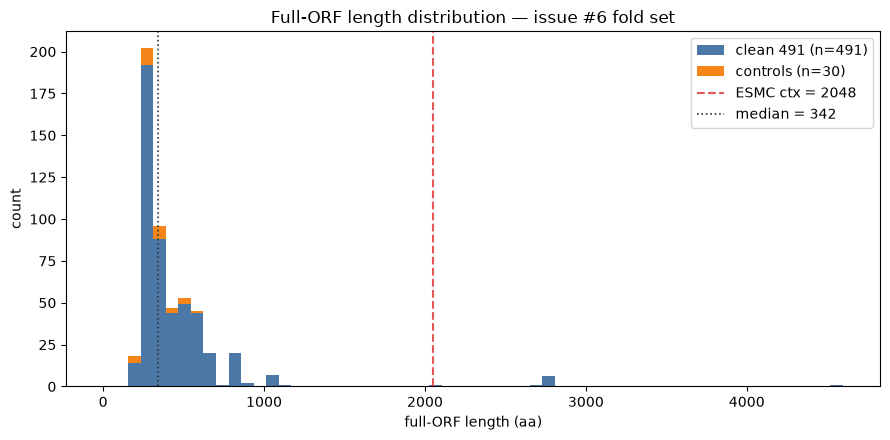

total residues = 232,167  ~= 151 min of pure fold time at 25.6 res/s (x repeats), before the O(L^2-3) long-protein penalty


In [10]:
import numpy as np
import matplotlib.pyplot as plt

assert OUT_FASTA.exists(), f"run the WSL seqkit command first to create {OUT_FASTA.name}"

# parse the bare-orfid FASTA -> length per ORFid
lengths, oid = {}, None
with open(OUT_FASTA) as fh:
    for line in fh:
        if line.startswith(">"):
            name = line[1:].strip()
            oid = int(name[3:]) if name.startswith("orf") else None
            lengths[oid] = 0
        elif oid is not None:
            lengths[oid] += len(line.strip().rstrip("*"))

found   = set(lengths)
missing = sorted(targets - found)
extra   = sorted(found - targets)
print(f"FASTA has {len(found)} ORFs (targets={len(targets)})")
if missing: print(f"  MISSING {len(missing)} target(s): {missing[:10]}{' ...' if len(missing)>10 else ''}")
if extra:   print(f"  unexpected {len(extra)}: {extra[:10]}")

# finalize metadata with lengths
with open(OUT_META, "w", newline="") as mh:
    w = csv.writer(mh, delimiter="\t")
    w.writerow(["orfid", "role", "orf_len", "pdb_id", "provenance", "core_range",
                "post_train_clean", "uniprot", "over_esmc_ctx"])
    for o in sorted(found):
        m = meta[o]
        w.writerow([o, role.get(o, "?"), lengths[o], m["pdb_id"], m["provenance"],
                    m["core_range"], m["post_train"], m["uniprot"], int(lengths[o] > ESMC_CONTEXT)])
print("wrote", OUT_META.name)

L_clean = [lengths[o] for o in found if role.get(o) == "clean"]
L_ctrl  = [lengths[o] for o in found if role.get(o) == "control"]
allL = np.array(L_clean + L_ctrl)
n_over = int((allL > ESMC_CONTEXT).sum())
print(f"\nn={allL.size}  min={allL.min()}  median={int(np.median(allL))}  mean={allL.mean():.0f}  "
      f"p90={int(np.percentile(allL,90))}  max={allL.max()}   |  {n_over} over {ESMC_CONTEXT}aa")

print(f"mode={np.bincount(allL).argmax()}  (count={np.bincount(allL).max()})")

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, max(allL.max(), ESMC_CONTEXT) + 50, 60)
ax.hist([L_clean, L_ctrl], bins=bins, stacked=True,
        label=[f"clean 491 (n={len(L_clean)})", f"controls (n={len(L_ctrl)})"],
        color=["#4C78A8", "#F58518"])
ax.axvline(ESMC_CONTEXT, color="#E45756", ls="--", lw=1.5, label=f"ESMC ctx = {ESMC_CONTEXT}")
ax.axvline(np.median(allL), color="#333", ls=":", lw=1.2, label=f"median = {int(np.median(allL))}")
ax.set_xlabel("full-ORF length (aa)"); ax.set_ylabel("count")
ax.set_title("Full-ORF length distribution — issue #6 fold set")
ax.legend(); fig.tight_layout(); plt.show()

tot_res = int(allL.sum())
print(f"total residues = {tot_res:,}  ~= {tot_res/25.6/60:.0f} min of pure fold time at 25.6 res/s "
      f"(x repeats), before the O(L^2-3) long-protein penalty")

### 2f. Sweep subset — direct-PDB, leakage-free (110 clean + controls)

This step was implemented after the above histogram was generated, to limit the amount of folding necessary for this hyperparameter experiment.

Restrict the sweep to clean ORFs that have **their own solved structure released after ESMFold2's
2021-09-30 cutoff** (a **post-2021 `direct` PDB, already local**) — the cleanest possible leakage-free
ground truth — plus the length-matched leakage controls (a pre-2021 direct PDB = the metric's
ceiling). 

This **drops the ~87 `via_uniprot` ORFs**: those map one ORFid to a whole UniProt's PDB
history (1970s→2020s), and picking a representative silently scored many clean ORFs against *pre-2021
(leaked)* or un-downloaded structures — the contamination we found in the first run. 


Result **~110
clean + 11 control = 121 ORFs**, every reference local and leakage-free. Writes `paramsweep_subset.fasta`
(fold input) + `paramsweep_subset_map.tsv` (orfid -> role / pdb_id / core_range / ref_post_train).

In [20]:
import csv, random
import numpy as np
from pathlib import Path

# --- subset window (aa) + control sampling (must match cell 2) ---
SUB_LO, SUB_HI = 225, 312
N_CONTROLS, SEED = 30, 0

REPO = Path.cwd()
while not (REPO / "resources").exists() and REPO != REPO.parent:
    REPO = REPO.parent
RES    = REPO / "resources" / "260706_issue6_foldpredictions"
PDBDIR = REPO / "notebooks" / "pdb_structures"
LOCAL  = {p.stem.upper() for p in PDBDIR.glob("*.cif")}          # PDBs already on disk

cands = sorted(RES.glob("*fold_orfs_clean491_plus_controls.fasta"))
assert cands, f"no full-ORF FASTA in {RES}"
FASTA_IN = cands[0]

# all map rows grouped per ORFid
rows_by_orf = {}
for d in csv.DictReader(open(RES / "pdb_orfid_map_dated.tsv"), delimiter="\t"):
    try:
        o = int(d["orfid"])
    except (ValueError, KeyError):
        continue
    rows_by_orf.setdefault(o, []).append(dict(
        pdb=d["pdb_id"], prov=d["provenance"].strip(),
        post=d["post_train_2021_09_30"].strip().lower() == "true",
        crange=d["core_range"], rel=d["initial_release_date"]))

def pick_direct_local(o, want_post):
    """A provenance==direct, post_train==want_post PDB for ORF o that is ALREADY LOCAL (else None).
    Deterministic: earliest release among the local candidates."""
    rr = [r for r in rows_by_orf.get(o, [])
          if r["prov"] == "direct" and r["post"] == want_post and r["pdb"].upper() in LOCAL]
    if not rr:
        return None
    rr.sort(key=lambda r: r["rel"])
    return rr[0]

# reproduce cell 2's control sample exactly (leakage-direct pool, seed 0, 30)
leak_direct = {o for o, rr in rows_by_orf.items()
               if any(r["prov"] == "direct" and not r["post"] for r in rr)}
random.seed(SEED)
controls_pool = set(random.sample(sorted(leak_direct), N_CONTROLS))

# sequences + lengths from the full-ORF FASTA
seqs, oid = {}, None
for line in open(FASTA_IN):
    if line.startswith(">"):
        oid = int(line[1:].strip()[3:]); seqs[oid] = []
    elif oid is not None:
        seqs[oid].append(line.strip().rstrip("*"))
seqs = {o: "".join(v) for o, v in seqs.items()}
lens = {o: len(s) for o, s in seqs.items()}

# clean = LOCAL post-2021 direct ref (leakage-free, ORF's own structure);
# control = sampled leakage ORF with a LOCAL pre-2021 direct ref (the ceiling).
sub_clean, sub_ctrl, ref = [], [], {}
for o in seqs:
    if not (SUB_LO <= lens[o] < SUB_HI):
        continue
    rc = pick_direct_local(o, want_post=True)
    if rc:
        sub_clean.append(o); ref[o] = ("clean", rc); continue
    if o in controls_pool:
        rk = pick_direct_local(o, want_post=False)
        if rk:
            sub_ctrl.append(o); ref[o] = ("control", rk)

sub_clean.sort(); sub_ctrl.sort()
subset = sub_clean + sub_ctrl
Ls = np.array([lens[o] for o in subset])
print(f"Option A subset: {len(sub_clean)} clean (post-2021 direct, local) + {len(sub_ctrl)} control "
      f"= {len(subset)} ORFs")
print(f"  length [{SUB_LO},{SUB_HI})  median={int(np.median(Ls))} max={Ls.max()}  total_res={Ls.sum():,}")

SUB_FASTA = RES / "paramsweep_subset.fasta"
SUB_META  = RES / "paramsweep_subset_map.tsv"
with open(SUB_FASTA, "w", newline="\n") as fa:
    for o in subset:
        fa.write(f">orf{o}\n")
        s = seqs[o]
        for i in range(0, len(s), 60):
            fa.write(s[i:i+60] + "\n")
with open(SUB_META, "w", newline="") as mh:
    w = csv.writer(mh, delimiter="\t")
    w.writerow(["orfid", "role", "pdb_id", "provenance", "core_range", "orf_len", "ref_post_train"])
    for o in subset:
        role, r = ref[o]
        w.writerow([o, role, r["pdb"], r["prov"], r["crange"], lens[o], r["post"]])

# every ref is local; clean refs post-2021, control refs pre-2021
assert all(r["pdb"].upper() in LOCAL for _, r in ref.values())
assert all(r["post"] for role, r in ref.values() if role == "clean")
assert all(not r["post"] for role, r in ref.values() if role == "control")
print(f"wrote {SUB_FASTA.name} ({len(subset)} seqs) + {SUB_META.name}  (all refs local + leakage-correct)")
print(f"est fold time @25.6 res/s (repeats=1): {Ls.sum()/25.6/60:.0f} min/config")

Option A subset: 110 clean (post-2021 direct, local) + 11 control = 121 ORFs
  length [225,312)  median=272 max=310  total_res=33,008
wrote paramsweep_subset.fasta (121 seqs) + paramsweep_subset_map.tsv  (all refs local + leakage-correct)
est fold time @25.6 res/s (repeats=1): 21 min/config


## 3. Quality and Speed Results

Results are reported for the following parameter combinations. Note that the Biohub paper reported results for both 10 and 20 loops, and reported that quality metrics stopped increasing after 68 diffusion steps.

1.  100 Steps, 20 Loops: Upper Ceiling
2.  68 Steps, 20 Loops Default Steps, Higher Loops
3.  68 Steps, 10 Loops Default Steps, Lower Loops
4.  32 Steps, 10 Loops: Lower the Steps
5.  68 Steps, 5 Loops: Lower the Loops
6.  32 Steps, 5 Loops: Lower Bound

I recognize that this is a small set of tests, but the main point of this testing was to confirm if lowering the parameters from the established defaults from the Biohub paper would significantly degrade the quality of the predictions relative to the ground truth on PETases.

In [ ]:
# Run these in PowerShell or WSL to configure the AWS CLI for the S3 bucket access.
"""
aws configure set aws_access_key_id <your-access-key-id>
aws configure set aws_secret_access_key <your-secret-access-key>
aws configure set aws_session_token <your-session-token>  # if using temporary credentials
aws configure set default.region us-east-1
"""

#### Scoring helper — `score_config()`

Scores this config's predictions (streamed from S3) against the local ground-truth PDBs via
`compare_predictions.py`. 

Primary metric = **`tm_ref`** (TM-score normalised by the experimental
structure). 

The **control** distribution should sit high (leakage/memorized = the metric's ceiling);
if it doesn't, the scoring is wrong, not the model. Safe to run mid-fold — ORFs not yet uploaded are
counted as `pred_missing` and skipped, so re-run as the fold completes.

> Needs **local AWS creds** to read the private predictions bucket (`petadex-protein-structures`).
> If the run 403s / errors on S3, export your temp STS keys locally (same keys as the VM upload) and
> re-run this cell.

`score_config(config)` runs `compare_predictions.py` for one hyperparameter config (predictions
streamed from S3, scored vs the local PDBs), prints the clean/control `tm_ref` summary, plots the
distribution, and stashes the per-ORF rows in `RESULTS[config]` for the final cross-config
comparison. Each Result cell below is then a one-liner. Pass `rerun=False` to reuse an existing
`cmp_<config>.tsv` without re-hitting S3.

In [24]:
import subprocess, sys, csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# repo-relative paths (independent of kernel cwd)
REPO = Path.cwd()
while not (REPO / "resources").exists() and REPO != REPO.parent:
    REPO = REPO.parent
RES    = REPO / "resources" / "260706_issue6_foldpredictions"
PDBDIR = REPO / "notebooks" / "pdb_structures"
S3_ROOT = "s3://petadex-protein-structures/esmfold2_paramsweep/"

RESULTS = {}   # config -> per-ORF rows, filled by score_config() for the final comparison

def score_config(config, rerun=True, plot=True):
    """Score one config's predictions vs ground-truth PDB. Returns per-ORF rows; also -> RESULTS[config].
    Needs local AWS creds to read the private predictions bucket (export temp STS keys if it 403s)."""
    out_tsv = RES / f"cmp_{config}.tsv"
    if rerun or not out_tsv.exists():
        cmd = [sys.executable, "compare_predictions.py",
               "--map", "paramsweep_subset_map.tsv", "--pdb-dir", str(PDBDIR),
               "--s3-pred", f"{S3_ROOT.rstrip(chr(47))}/{config}/", "--label", config, "--out", f"cmp_{config}.tsv"]
        r = subprocess.run(cmd, cwd=RES, capture_output=True, text=True)
        print(r.stdout[-2500:])
        if r.returncode != 0:
            print("!! compare_predictions failed\n", r.stderr[-1500:])
            return None

    rows = list(csv.DictReader(open(out_tsv), delimiter="\t"))
    ok = [x for x in rows if x["status"] == "ok"]
    tmref = lambda role: [float(x["tm_ref"]) for x in ok
                          if x["role"] == role and x["tm_ref"] not in ("", "None")]
    clean, ctrl = tmref("clean"), tmref("control")
    print(f"\n[{config}]")
    for name, v in (("clean", clean), ("control", ctrl)):
        if v:
            print(f"  {name:<8} n={len(v):<4} tm_ref median={np.median(v):.3f} "
                  f"mean={np.mean(v):.3f} min={min(v):.3f} max={max(v):.3f}")

    if plot and (clean or ctrl):
        # two panels: full 0-1 range (with the TM 0.5 "same fold" reference), and a 0.9-1.0 zoom
        # where the saturated clean/control spread is actually visible.
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        panels = [(0.0, 1.0, np.linspace(0, 1, 41),     "full range (0-1)",  True),
                  (0.9, 1.0, np.linspace(0.9, 1.0, 41), "zoom (0.9-1.0)",    False)]
        for ax, (lo, hi, bins, sub, show05) in zip(axes, panels):
            if clean: ax.hist(clean, bins=bins, alpha=.7, color="#4C78A8", label=f"clean (n={len(clean)})")
            if ctrl:  ax.hist(ctrl,  bins=bins, alpha=.7, color="#F58518", label=f"control (n={len(ctrl)})")
            if show05: ax.axvline(0.5, color="#888", ls=":", label="TM 0.5 (same fold)")
            ax.set_xlim(lo, hi)
            ax.set_xlabel("tm_ref  (TM-score vs experimental PDB)"); ax.set_ylabel("count")
            ax.set_title(sub); ax.legend()
        fig.suptitle(f"{config}: prediction vs ground-truth PDB")
        fig.tight_layout(); plt.show()

    RESULTS[config] = rows
    return rows

#### Result 1 — s100_l20 (100 steps, 20 loops; upper ceiling)
Runtime: 39m:49s


rf4920202   clean   7XTU   ok             TM_ref=0.9861
  orf4920203   clean   8X6V   ok             TM_ref=0.9965
  orf4939867   clean   7VVE   ok             TM_ref=0.9916
  orf4939868   clean   7YKO   ok             TM_ref=0.9937
  orf4939869   clean   8H5K   ok             TM_ref=0.9918
  orf4960193   clean   7EOA   ok             TM_ref=0.9931
  orf4960194   clean   7Q4H   ok             TM_ref=0.9896
  orf4960195   clean   7Q4H   ok             TM_ref=0.9893
  orf4960196   clean   7Q4J   ok             TM_ref=0.9729
  orf4960197   clean   7Q4J   ok             TM_ref=0.9761
  orf4981588   clean   7E31   ok             TM_ref=0.9936
  orf4981589   clean   7XRI   ok             TM_ref=0.9939
  orf5035114   clean   7E50   ok             TM_ref=0.9814
  orf5035115   clean   8ILT   ok             TM_ref=0.9599
  orf5086669   clean   8SKM   ok             TM_ref=0.9897
  orf5086670   clean   8SLJ   ok             TM_ref=0.9889
  orf5126692   clean   7XYD   ok             TM_ref=0.982
 

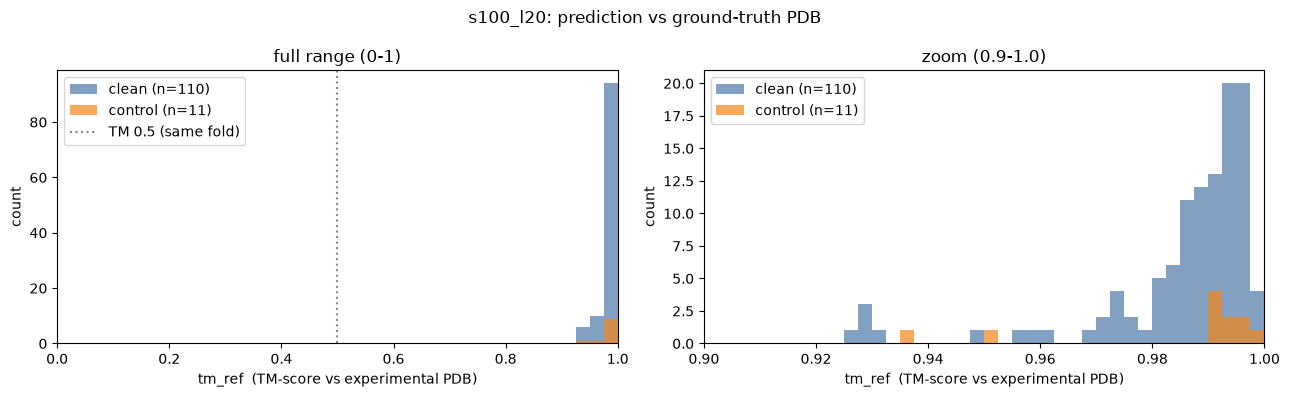

In [25]:
rows = score_config("s100_l20")   # 100 steps, 20 loops -- upper ceiling

#### Result 2 — s68_l20 (68 steps, 20 loops; default-higher loops)
Runtime: 39m6s


  orf4920202   clean   7XTU   ok             TM_ref=0.9869
  orf4920203   clean   8X6V   ok             TM_ref=0.9962
  orf4939867   clean   7VVE   ok             TM_ref=0.9901
  orf4939868   clean   7YKO   ok             TM_ref=0.992
  orf4939869   clean   8H5K   ok             TM_ref=0.9941
  orf4960193   clean   7EOA   ok             TM_ref=0.9932
  orf4960194   clean   7Q4H   ok             TM_ref=0.99
  orf4960195   clean   7Q4H   ok             TM_ref=0.9892
  orf4960196   clean   7Q4J   ok             TM_ref=0.9778
  orf4960197   clean   7Q4J   ok             TM_ref=0.975
  orf4981588   clean   7E31   ok             TM_ref=0.994
  orf4981589   clean   7XRI   ok             TM_ref=0.9939
  orf5035114   clean   7E50   ok             TM_ref=0.9821
  orf5035115   clean   8ILT   ok             TM_ref=0.9635
  orf5086669   clean   8SKM   ok             TM_ref=0.9898
  orf5086670   clean   8SLJ   ok             TM_ref=0.9892
  orf5126692   clean   7XYD   ok             TM_ref=0.985
  

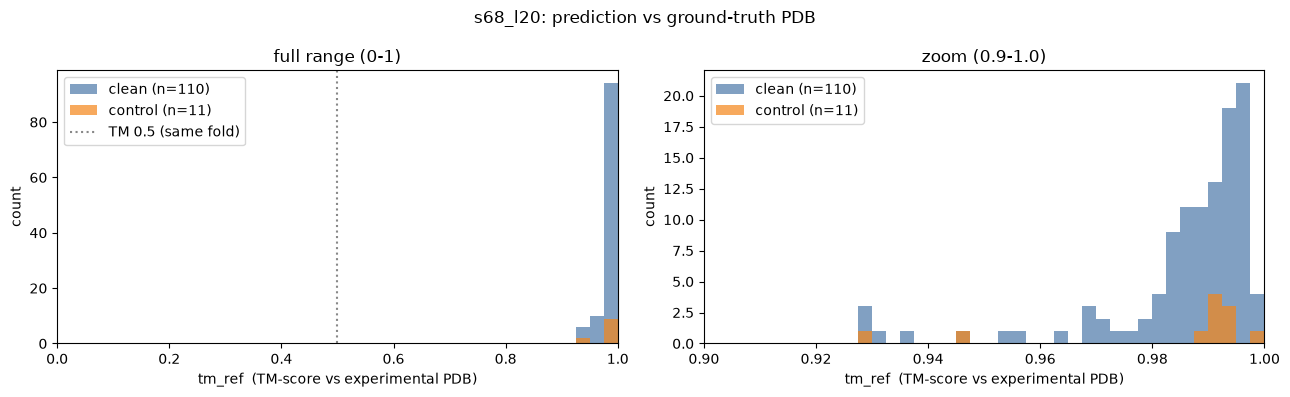

In [27]:
rows = score_config("s68_l20")

#### Result 3 — s68_l10 (68 steps, 10 loops; default-lower loops)

Runtime: 23m:09s

f4920202   clean   7XTU   ok             TM_ref=0.9871
  orf4920203   clean   8X6V   ok             TM_ref=0.9963
  orf4939867   clean   7VVE   ok             TM_ref=0.9923
  orf4939868   clean   7YKO   ok             TM_ref=0.9902
  orf4939869   clean   8H5K   ok             TM_ref=0.991
  orf4960193   clean   7EOA   ok             TM_ref=0.9934
  orf4960194   clean   7Q4H   ok             TM_ref=0.9897
  orf4960195   clean   7Q4H   ok             TM_ref=0.9846
  orf4960196   clean   7Q4J   ok             TM_ref=0.9798
  orf4960197   clean   7Q4J   ok             TM_ref=0.9834
  orf4981588   clean   7E31   ok             TM_ref=0.9936
  orf4981589   clean   7XRI   ok             TM_ref=0.9943
  orf5035114   clean   7E50   ok             TM_ref=0.9789
  orf5035115   clean   8ILT   ok             TM_ref=0.9547
  orf5086669   clean   8SKM   ok             TM_ref=0.9895
  orf5086670   clean   8SLJ   ok             TM_ref=0.9879
  orf5126692   clean   7XYD   ok             TM_ref=0.9861
  

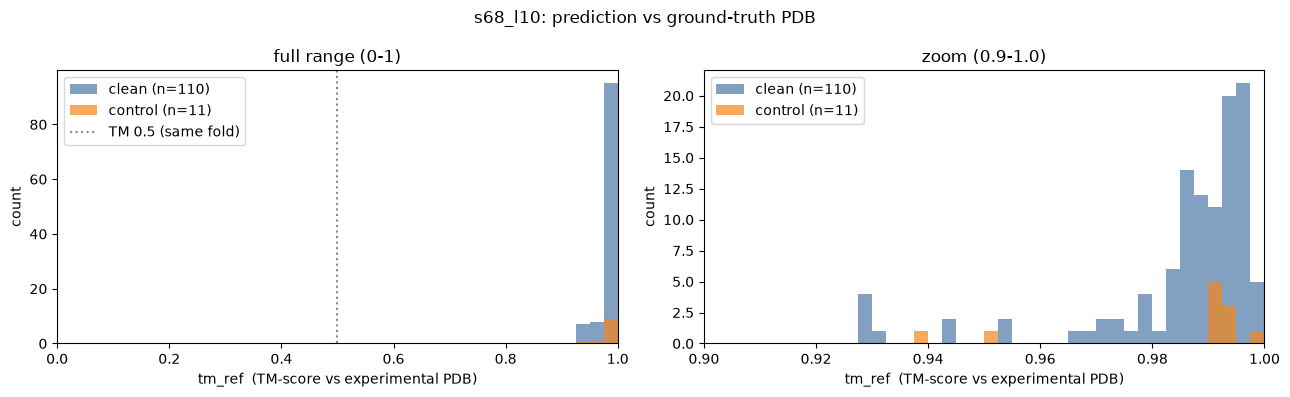

In [28]:
rows = score_config("s68_l10")

#### Result 4 — s32_l10 (32 steps, 10 loops; lower steps)

Runtime: 22m:08s

f4920202   clean   7XTU   ok             TM_ref=0.9909
  orf4920203   clean   8X6V   ok             TM_ref=0.9963
  orf4939867   clean   7VVE   ok             TM_ref=0.9923
  orf4939868   clean   7YKO   ok             TM_ref=0.9923
  orf4939869   clean   8H5K   ok             TM_ref=0.9942
  orf4960193   clean   7EOA   ok             TM_ref=0.9961
  orf4960194   clean   7Q4H   ok             TM_ref=0.9901
  orf4960195   clean   7Q4H   ok             TM_ref=0.9896
  orf4960196   clean   7Q4J   ok             TM_ref=0.9855
  orf4960197   clean   7Q4J   ok             TM_ref=0.9821
  orf4981588   clean   7E31   ok             TM_ref=0.9932
  orf4981589   clean   7XRI   ok             TM_ref=0.994
  orf5035114   clean   7E50   ok             TM_ref=0.9804
  orf5035115   clean   8ILT   ok             TM_ref=0.9592
  orf5086669   clean   8SKM   ok             TM_ref=0.9904
  orf5086670   clean   8SLJ   ok             TM_ref=0.9901
  orf5126692   clean   7XYD   ok             TM_ref=0.9819
  

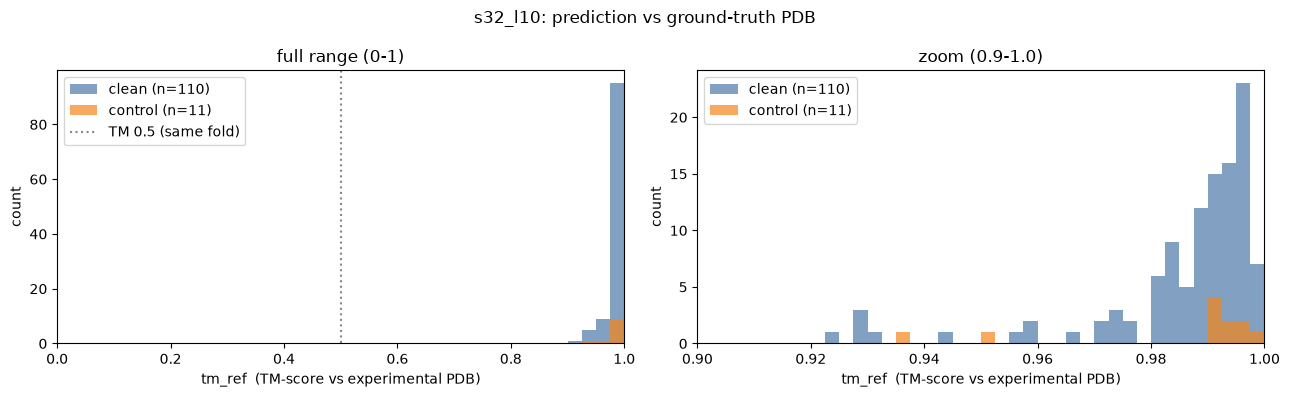

In [29]:
rows = score_config("s32_l10")

#### Result 5 — s68_l5 (68 steps, 5 loops; lower loops)

Runtime: 15:27

  orf4920202   clean   7XTU   ok             TM_ref=0.9883
  orf4920203   clean   8X6V   ok             TM_ref=0.9963
  orf4939867   clean   7VVE   ok             TM_ref=0.9925
  orf4939868   clean   7YKO   ok             TM_ref=0.9946
  orf4939869   clean   8H5K   ok             TM_ref=0.9936
  orf4960193   clean   7EOA   ok             TM_ref=0.996
  orf4960194   clean   7Q4H   ok             TM_ref=0.9906
  orf4960195   clean   7Q4H   ok             TM_ref=0.9872
  orf4960196   clean   7Q4J   ok             TM_ref=0.9811
  orf4960197   clean   7Q4J   ok             TM_ref=0.9846
  orf4981588   clean   7E31   ok             TM_ref=0.9937
  orf4981589   clean   7XRI   ok             TM_ref=0.9942
  orf5035114   clean   7E50   ok             TM_ref=0.9783
  orf5035115   clean   8ILT   ok             TM_ref=0.9497
  orf5086669   clean   8SKM   ok             TM_ref=0.9914
  orf5086670   clean   8SLJ   ok             TM_ref=0.9893
  orf5126692   clean   7XYD   ok             TM_ref=0.983

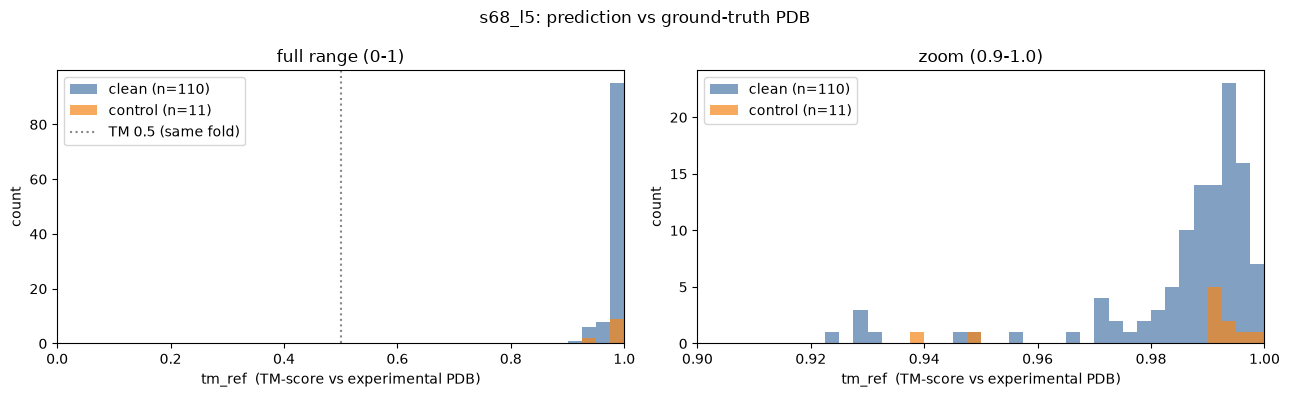

In [32]:
rows = score_config("s68_l5")

#### Result 6 — s32_l5 (32 steps, 5 loops; lower bound)

Runtime: 10m:51s

orf4920202   clean   7XTU   ok             TM_ref=0.9877
  orf4920203   clean   8X6V   ok             TM_ref=0.9964
  orf4939867   clean   7VVE   ok             TM_ref=0.9928
  orf4939868   clean   7YKO   ok             TM_ref=0.9945
  orf4939869   clean   8H5K   ok             TM_ref=0.9943
  orf4960193   clean   7EOA   ok             TM_ref=0.9965
  orf4960194   clean   7Q4H   ok             TM_ref=0.9861
  orf4960195   clean   7Q4H   ok             TM_ref=0.9855
  orf4960196   clean   7Q4J   ok             TM_ref=0.9731
  orf4960197   clean   7Q4J   ok             TM_ref=0.9764
  orf4981588   clean   7E31   ok             TM_ref=0.9937
  orf4981589   clean   7XRI   ok             TM_ref=0.9941
  orf5035114   clean   7E50   ok             TM_ref=0.9808
  orf5035115   clean   8ILT   ok             TM_ref=0.9762
  orf5086669   clean   8SKM   ok             TM_ref=0.9897
  orf5086670   clean   8SLJ   ok             TM_ref=0.9881
  orf5126692   clean   7XYD   ok             TM_ref=0.9835

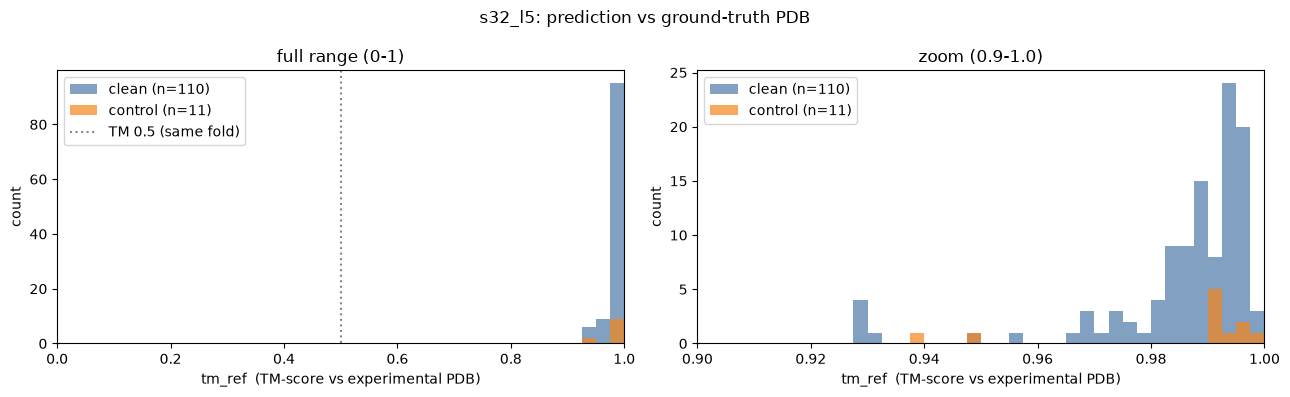

In [31]:
rows = score_config("s32_l5")

### 4. Self-Confidence Results — pLDDT / pTM from the S3 metrics JSONs

Global TM is saturated (~0.99 for every config), so it can't separate the parameter combos. The
model's **own confidence** is an independent, ground-truth-free signal — and it covers *every* folded
ORF, not just the 121 with a usable PDB. `confidence_dist(config)` reads each metrics JSON straight
from S3, pulling `confidence.mean_plddt` and `confidence.ptm`. Those scalars sit *before* the large
per-residue/PAE arrays in the file, so we Range-GET only the first few KB per object — fast enough to
sweep all six configs. `compare_confidence()` then overlays the distributions, paired on the ORFs
present in every config.

In [36]:
# Needs the paths/creds from the score_config cell (run that first for S3_ROOT + AWS creds).
import boto3, re
import numpy as np
import matplotlib.pyplot as plt

_S3 = boto3.client("s3")
_BUCKET, _, _ROOT = S3_ROOT[len("s3://"):].partition("/")   # reuse score_config's S3_ROOT
_ROOT = _ROOT.strip("/")
_RX = {k: re.compile(p) for k, p in {
    "mean_plddt": r'"mean_plddt":\s*([\d.]+)',
    "ptm":        r'"ptm":\s*([\d.]+)',
    "seq_len":    r'"seq_len":\s*(\d+)',
    "wall_s":     r'"wall_s_median":\s*([\d.]+)',
}.items()}

CONF = {}   # config -> list of per-ORF confidence records

def confidence_dist(config, plot=True):
    """Distribution of self-confidence (mean pLDDT, pTM) over every folded ORF for `config`, read
    straight from the S3 metrics JSONs (no ground-truth PDB needed). Returns records; -> CONF[config]."""
    keys, tok = [], None
    while True:                                             # list metrics/*.json (paginated)
        kw = dict(Bucket=_BUCKET, Prefix=f"{_ROOT}/{config}/metrics/")
        if tok: kw["ContinuationToken"] = tok
        r = _S3.list_objects_v2(**kw)
        keys += [o["Key"] for o in r.get("Contents", []) if o["Key"].endswith(".json")]
        if not r.get("IsTruncated"): break
        tok = r["NextContinuationToken"]

    recs = []
    for k in keys:                                          # Range-GET the head (scalars precede arrays)
        head = _S3.get_object(Bucket=_BUCKET, Key=k, Range="bytes=0-4095")["Body"].read().decode(errors="replace")
        rec = {"orfid": k.rsplit("/", 1)[-1][3:-5]}         # strip 'orf' prefix + '.json'
        for name, rx in _RX.items():
            m = rx.search(head)
            rec[name] = float(m.group(1)) if m else None
        recs.append(rec)

    pl = [x["mean_plddt"] for x in recs if x["mean_plddt"] is not None]
    pt = [x["ptm"] for x in recs if x["ptm"] is not None]
    print(f"[{config}] n={len(pl)}  pLDDT median={np.median(pl):.2f} mean={np.mean(pl):.2f} "
          f"min={min(pl):.2f} max={max(pl):.2f}  |  pTM median={np.median(pt):.3f} min={min(pt):.3f}")

    if plot and pl:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        ax[0].hist(pl, bins=np.linspace(80, 100, 41), color="#4C78A8", alpha=.8)
        ax[0].set_xlabel("mean pLDDT"); ax[0].set_ylabel("ORFs"); ax[0].set_title(f"{config}: mean pLDDT")
        ax[1].hist(pt, bins=np.linspace(0.7, 1.0, 31), color="#54A24B", alpha=.8)
        ax[1].set_xlabel("pTM"); ax[1].set_ylabel("ORFs"); ax[1].set_title(f"{config}: pTM")
        fig.tight_layout(); plt.show()

    CONF[config] = recs
    return recs

paired on n=121 ORFs present in every config  (Δ vs s100_l20)

config     pLDDT med  median Δ   mean Δ  worst Δ
s100_l20       95.30    +0.000   +0.000    +0.00
s68_l20        95.37    -0.008   -0.030    -0.96
s68_l10        95.18    +0.027   -0.005    -1.41
s68_l5         95.06    +0.002   -0.147    -2.48
s32_l10        95.28    +0.072   +0.056    -1.58
s32_l5         95.12    +0.034   -0.088    -2.41


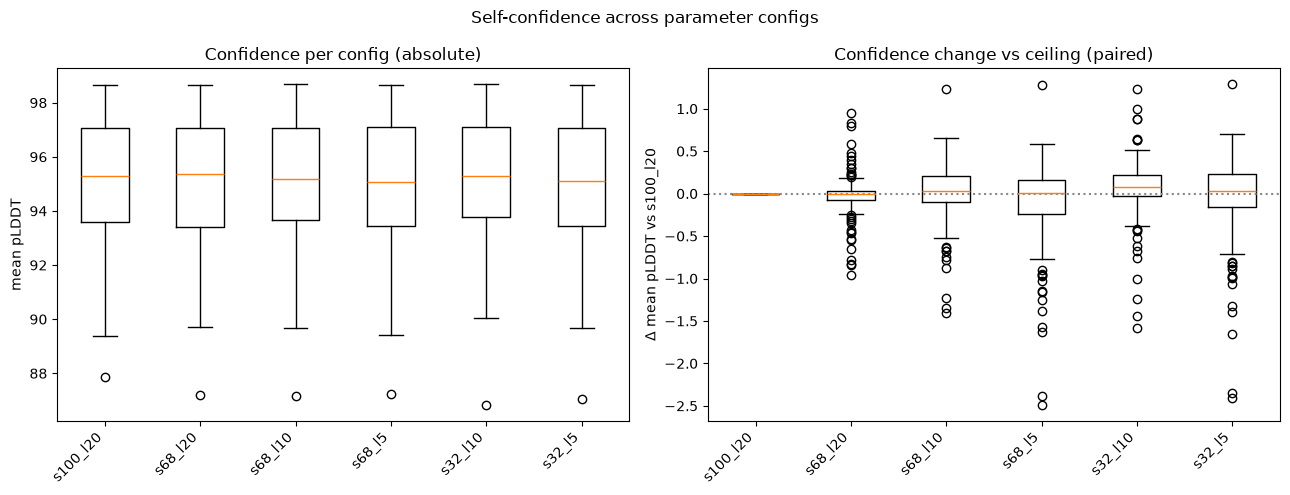

In [35]:
# Cross-config comparison: pull any missing configs, then paired table + box plots.
# Box plots (one per config) instead of overlaid histograms -- when the distributions are nearly
# identical, overlaid step-histograms just tangle; a box per config shows "all the same" at a glance.
CONFIGS = ["s100_l20", "s68_l20", "s68_l10", "s68_l5", "s32_l10", "s32_l5"]
for c in CONFIGS:
    if c not in CONF:
        confidence_dist(c, plot=False)

common = set.intersection(*[{r["orfid"] for r in CONF[c] if r["mean_plddt"] is not None} for c in CONFIGS])
common = sorted(common)
ref = CONFIGS[0]
refpl = {r["orfid"]: r["mean_plddt"] for r in CONF[ref]}
print(f"paired on n={len(common)} ORFs present in every config  (Δ vs {ref})\n")
print(f"{'config':<10} {'pLDDT med':>9} {'median Δ':>9} {'mean Δ':>8} {'worst Δ':>8}")

absvals, deltas = [], []
for c in CONFIGS:
    m = {r["orfid"]: r["mean_plddt"] for r in CONF[c]}
    vals = [m[o] for o in common]
    d = [m[o] - refpl[o] for o in common]
    print(f"{c:<10} {np.median(vals):>9.2f} {np.median(d):>+9.3f} {np.mean(d):>+8.3f} {min(d):>+8.2f}")
    absvals.append(vals); deltas.append(d)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# left: absolute confidence per config -- boxes all sit at ~95 (no real difference)
ax[0].boxplot(absvals)
ax[0].set_xticks(range(1, len(CONFIGS) + 1)); ax[0].set_xticklabels(CONFIGS, rotation=45, ha="right")
ax[0].set_ylabel("mean pLDDT"); ax[0].set_title("Confidence per config (absolute)")
# right: paired change vs the ceiling -- centered on 0; watch the lower whiskers on the l5 configs
ax[1].boxplot(deltas)
ax[1].axhline(0, color="#888", ls=":")
ax[1].set_xticks(range(1, len(CONFIGS) + 1)); ax[1].set_xticklabels(CONFIGS, rotation=45, ha="right")
ax[1].set_ylabel(f"Δ mean pLDDT vs {ref}"); ax[1].set_title("Confidence change vs ceiling (paired)")
fig.suptitle("Self-confidence across parameter configs"); fig.tight_layout(); plt.show()

## 5. Conclusions

Since there is such little difference in both the TM-ref scores and self confidence metrics between the groups, my conclusions are determined by prior research and the runtime values from this experiment.

After doing this analysis, I think that we should proceed with the default parameters of 68 diffusion steps and 10 loops. The 10 loops will make it the full folding significantly less time-consuming while the 68 diffusion steps are supported by the original study. 

Additionally, this experiment was originally supposed to examine active-site-specific metrics to assess if the param tuning would affect ESMFold2's PETase active site folding which is the most important region. However, given the high identity of predictions between the different param combos, I have decided to forgo this analysis.